In [85]:
import numpy as np
import pandas as pd 

In [86]:
df = pd.read_csv("/Users/apple/Desktop/AI-ML/Datasets/Titanic-Dataset.csv", usecols=['Age', 'Fare', 'Survived'])

In [87]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [88]:
from scipy.stats import stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [89]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [90]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

df[['Age']] = imputer.fit_transform(df[['Age']])

In [91]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [92]:
X = df.iloc[:, 1:3]
y = df.iloc[:, 0]

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


Text(0.5, 1.0, 'Age PDF')

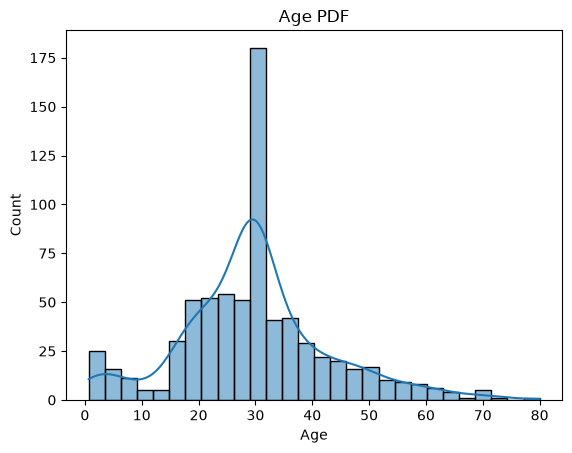

In [94]:
sns.histplot(X_train['Age'], kde=True)
plt.title('Age PDF')

Text(0.5, 1.0, 'Fare PDF')

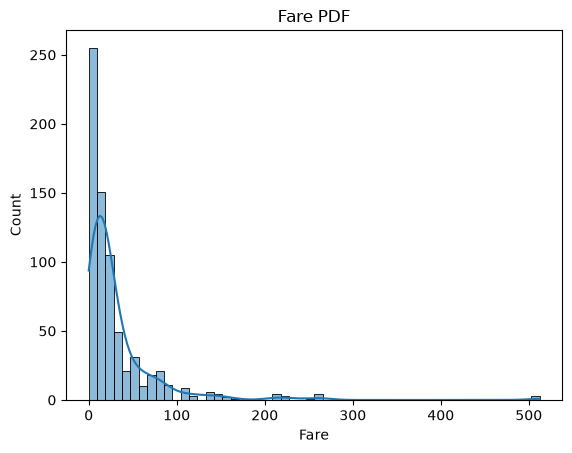

In [95]:
sns.histplot(X_train['Fare'], kde=True)
plt.title('Fare PDF')

In [96]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [97]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)
    
y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6983240223463687
Accuracy DT 0.6815642458100558


In [98]:
trf = FunctionTransformer(func=np.log1p)

In [99]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.fit_transform(X_test)

In [100]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
    
y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.7039106145251397
Accuracy DT 0.6759776536312849


In [101]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.655505617977528


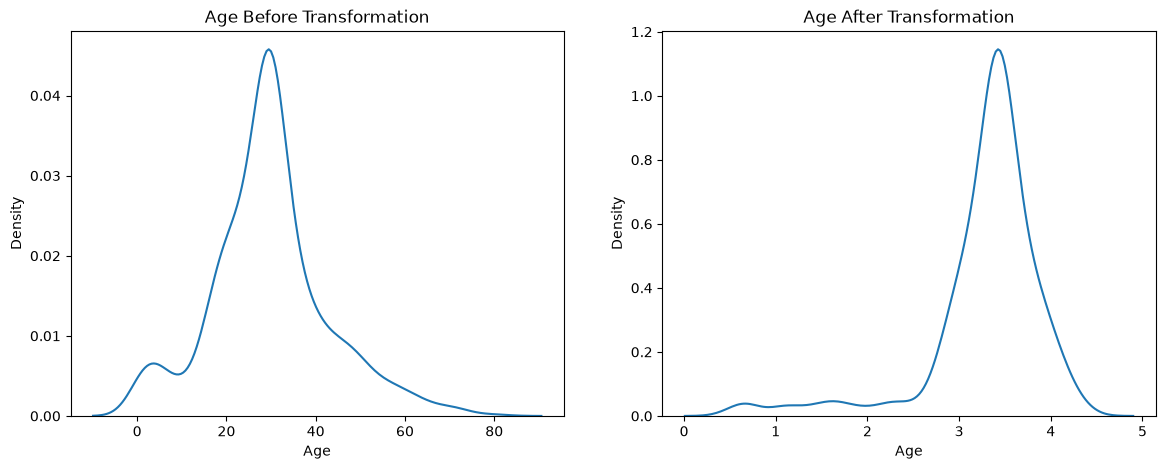

In [102]:
plt.figure(figsize=(14, 5))

plt.subplot(121)
sns.kdeplot(X_train['Age'].dropna())
plt.title('Age Before Transformation')

plt.subplot(122)
sns.kdeplot(X_train_transformed['Age'].dropna())
plt.title('Age After Transformation')

plt.show()

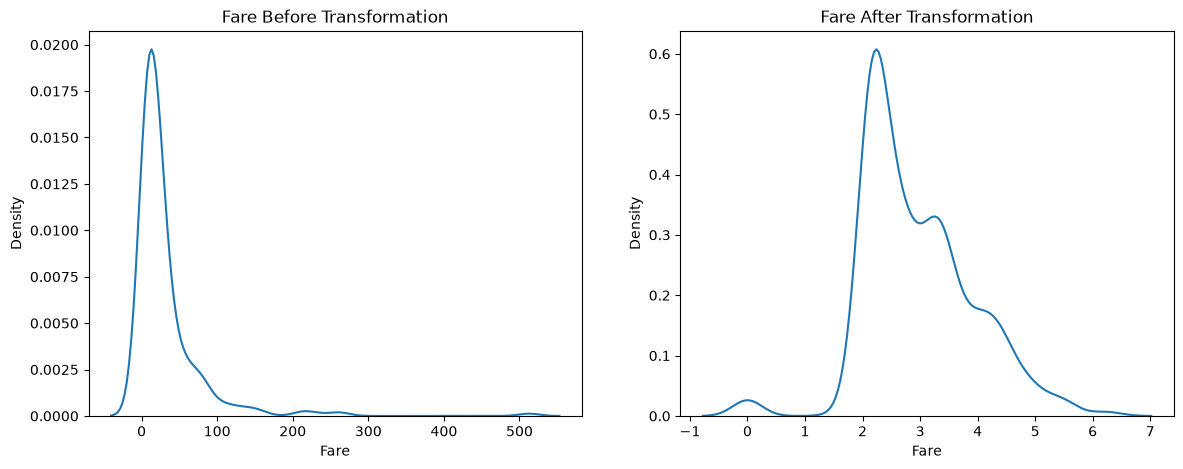

In [103]:
plt.figure(figsize=(14, 5))

plt.subplot(121)
sns.kdeplot(X_train['Fare'].dropna())
plt.title('Fare Before Transformation')

plt.subplot(122)
sns.kdeplot(X_train_transformed['Fare'].dropna())
plt.title('Fare After Transformation')

plt.show()

In [104]:
# Now only apply to fare 
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [105]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)
    
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6703910614525139


In [106]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6666916354556804
